In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
df=pd.read_csv('insurance.csv')

In [18]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [19]:
df.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


In [20]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


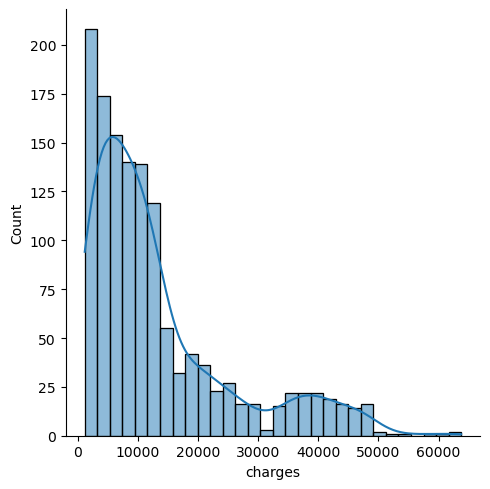

In [21]:
sns.displot(x=df.charges,kde=True)

In [22]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

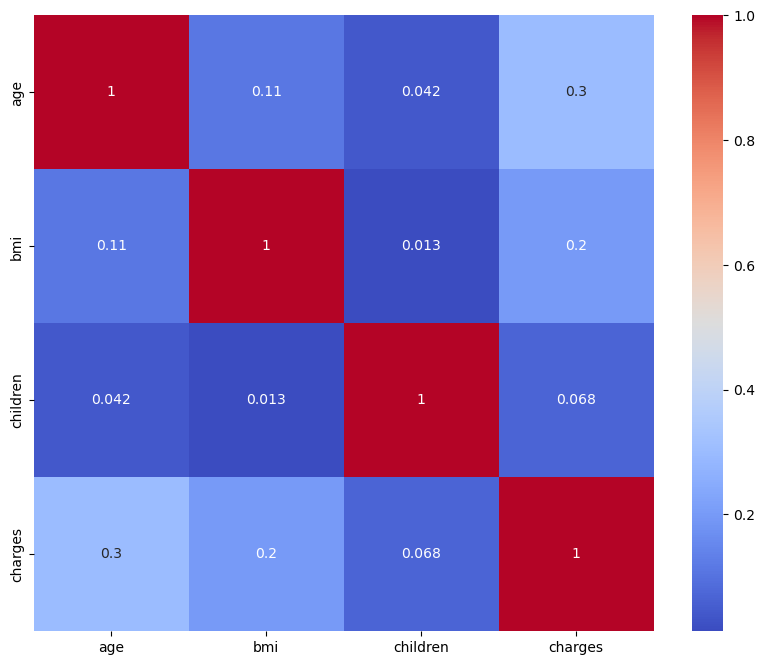

In [23]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm')
plt.show()

In [25]:
a=['smoker']
for col in a:
    df[col]=df[col].map({'yes':1,'no':0})

In [26]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,1,southwest,16884.92400
1,18,male,33.770,1,0,southeast,1725.55230
2,28,male,33.000,3,0,southeast,4449.46200
3,33,male,22.705,0,0,northwest,21984.47061
4,32,male,28.880,0,0,northwest,3866.85520


In [28]:
df=pd.get_dummies(df,columns=['sex','region'],drop_first=True)

In [29]:
df.head()

,age,bmi,children,smoker,charges,sex_male,region_northwest,region_southeast,region_southwest
0,19,27.900,0,1,16884.92400,False,False,False,True
1,18,33.770,1,0,1725.55230,True,False,True,False
2,28,33.000,3,0,4449.46200,True,False,True,False
3,33,22.705,0,0,21984.47061,True,True,False,False
4,32,28.880,0,0,3866.85520,True,True,False,False


In [30]:
X=df.drop('charges',axis=1)
y=df['charges']

In [31]:
X.head()

,age,bmi,children,smoker,sex_male,region_northwest,region_southeast,region_southwest
0,19,27.900,0,1,False,False,False,True
1,18,33.770,1,0,True,False,True,False
2,28,33.000,3,0,True,False,True,False
3,33,22.705,0,0,True,True,False,False
4,32,28.880,0,0,True,True,False,False


In [32]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)


In [33]:
X_train.shape

(1070, 8)

In [34]:
X_test.shape

(268, 8)

In [38]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [41]:
model=LinearRegression()
model.fit(X_train_scaled,y_train)
y_predict=model.predict(X_test_scaled)


In [42]:
import math
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
r2=r2_score(y_test,y_predict)
print(r2)
mse=mean_squared_error(y_test,y_predict)
print(mse)
mae=mean_absolute_error(y_test,y_predict)
print(mae)
rmse=np.sqrt(mse)
print(rmse)

0.7835929767120723
33596915.85136147
4181.194473753652
5796.2846592762735


In [45]:
from sklearn.linear_model import Lasso
lasso=Lasso(alpha=0.1)
lasso.fit(X_train_scaled,y_train)
y_pred=lasso.predict(X_test_scaled)

In [46]:
r2=r2_score(y_test,y_pred)
print(r2)
mse=mean_squared_error(y_test,y_pred)
print(mse)
mae=mean_absolute_error(y_test,y_pred)
print(mae)
rmse=np.sqrt(mse)
print(rmse)

0.7835902606415075
33597337.51787128
4181.226049201143
5796.321033023558


In [47]:
from sklearn.linear_model import Ridge
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_test_scaled)
from sklearn.metrics import r2_score, mean_absolute_error
print("R2 Score:", r2_score(y_test, y_pred_ridge))
print("MAE:", mean_absolute_error(y_test, y_pred_ridge))

R2 Score: 0.7835410749121385
MAE: 4182.796596583267
